In [2]:
! pip install tensorflow


In [3]:
! pip install keras

In [4]:
! pip install   --upgrade tensorflow

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
from tensorflow.keras.utils import image_dataset_from_directory # type: ignore

In [3]:
training_set = tf.keras.utils.image_dataset_from_directory(
    "./train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 76515 files belonging to 4 classes.


In [4]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    "./val",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 21861 files belonging to 4 classes.


In [5]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [6]:
INPUT_SHAPE = (224,224,3)

In [7]:
import keras
mobnet = tf.keras.applications.MobileNetV3Large(
    input_shape=(INPUT_SHAPE),
    alpha=1.0,
    minimalistic=False,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    classes=1000,
    pooling=None,
    dropout_rate=0.2,
    classifier_activation="softmax",
    include_preprocessing=True,
    # name="MobileNetV3Large",
)

In [9]:
model = tf.keras.models.Sequential()

In [10]:
model.add(tf.keras.Input(shape=INPUT_SHAPE))

In [11]:
model.add(mobnet)

In [12]:
model.add(tf.keras.layers.Dense(units = 4,activation="softmax"))

In [13]:
metrics_list = ["accuracy",tf.keras.metrics.F1Score()]

In [14]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=metrics_list)

In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 1000)           │     5,507,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         4,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,511,436 (21.02 MB)

 Trainable params: 5,487,036 (20.93 MB)

 Non-trainable params: 24,400 (95.31 KB)

In [17]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 6445s 3s/step - accuracy: 0.8002 - f1_score: 0.4391 - loss: 1.2027 - val_accuracy: 0.8078 - val_f1_score: 0.4431 - val_loss: 0.9394
Epoch 2/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 6797s 3s/step - accuracy: 0.8872 - f1_score: 0.6934 - loss: 0.8767 - val_accuracy: 0.8871 - val_f1_score: 0.8428 - val_loss: 0.7582
Epoch 3/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 6117s 3s/step - accuracy: 0.9503 - f1_score: 0.9146 - loss: 0.6632 - val_accuracy: 0.9596 - val_f1_score: 0.9290 - val_loss: 0.5432
Epoch 4/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 6306s 3s/step - accuracy: 0.9533 - f1_score: 0.9207 - loss: 0.5143 - val_accuracy: 0.9592 - val_f1_score: 0.9301 - val_loss: 0.4240
Epoch 5/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 31134s 13s/step - accuracy: 0.9594 - f1_score: 0.9312 - loss: 0.4002 - val_accuracy: 0.9645 - val_f1_score: 0.9394 - val_loss: 0.3322
Epoch 6/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 6334s 3s/step - accuracy: 0.9674 - f1_score: 0.9439 - loss: 0.3124 - val_accuracy: 0.9

In [18]:
model.save("Trained_Model.keras")

In [20]:
# Saving history
import pickle


with open('Training_history.pkl', 'wb') as f:
    pickle.dump(training_history.history, f)

In [21]:
#Reloading History from pickle
with open('Training_history.pkl', 'rb') as f:
    load_history = pickle.load(f)
load_history

{'accuracy': [0.8034502863883972,
  0.9092073440551758,
  0.9532510042190552,
  0.9555250406265259,
  0.9625955820083618,
  0.9681631326675415,
  0.9729726314544678,
  0.9768019318580627,
  0.9795072674751282,
  0.9829576015472412],
 'f1_score': [<tf.Tensor: shape=(4,), dtype=float32, numpy=array([0.8089211, 0.       , 0.       , 0.9531283], dtype=float32)>,
  <tf.Tensor: shape=(4,), dtype=float32, numpy=array([0.9039375 , 0.8953879 , 0.39589366, 0.97483706], dtype=float32)>,
  <tf.Tensor: shape=(4,), dtype=float32, numpy=array([0.9598171, 0.9194847, 0.8198778, 0.9786207], dtype=float32)>,
  <tf.Tensor: shape=(4,), dtype=float32, numpy=array([0.9619896 , 0.93079984, 0.82538927, 0.9794157 ], dtype=float32)>,
  <tf.Tensor: shape=(4,), dtype=float32, numpy=array([0.9676575 , 0.94261783, 0.8513491 , 0.98326176], dtype=float32)>,
  <tf.Tensor: shape=(4,), dtype=float32, numpy=array([0.9730683 , 0.9520755 , 0.8714693 , 0.98514795], dtype=float32)>,
  <tf.Tensor: shape=(4,), dtype=float32, nu

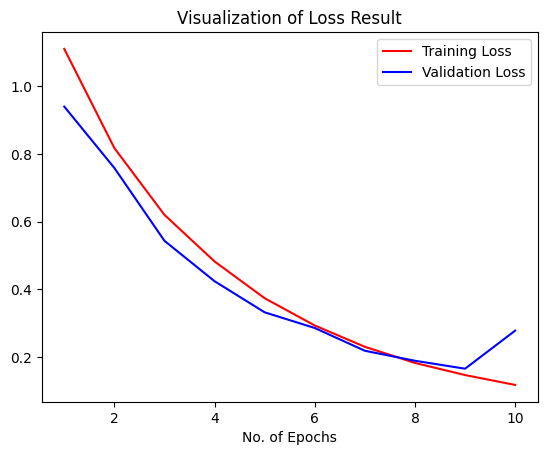

In [23]:
#Loss Visualization
epochs = [i for i in range(1,11)]
plt.plot(epochs,load_history['loss'],color='red',label='Training Loss')
plt.plot(epochs,load_history['val_loss'],color='blue',label='Validation Loss')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Loss Result')
plt.legend()
plt.show()

In [24]:
test_set = validation_set = image_dataset_from_directory(
    'test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=64,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 10933 files belonging to 4 classes.


In [25]:
test_loss,test_acc,f1_score = model.evaluate(test_set)

171/171 ━━━━━━━━━━━━━━━━━━━━ 169s 987ms/step - accuracy: 0.9262 - f1_score: 0.8920 - loss: 0.2724


In [26]:
test_loss

0.27730152010917664

In [27]:
test_acc

0.9241745471954346

In [28]:
f1_score

<tf.Tensor: shape=(4,), dtype=float32, numpy=array([0.96126133, 0.7826689 , 0.85627276, 0.948908  ], dtype=float32)>

In [ ]:
model = tf.keras.models.load_model("Trained_Model.h5")

In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 1000)           │     5,507,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         4,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,485,510 (62.89 MB)

 Trainable params: 5,487,036 (20.93 MB)

 Non-trainable params: 24,400 (95.31 KB)

 Optimizer params: 10,974,074 (41.86 MB)

In [30]:
test_set = validation_set = image_dataset_from_directory(
    'test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=64,
    image_size=(224, 224),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 10933 files belonging to 4 classes.


In [31]:
##Computing True labels from test set
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [33]:
Y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3])>

In [34]:
##Computing Predicted labels using test set
predicted_categories = model.predict(test_set)
Y_pred = tf.argmax(predicted_categories, axis=1)

171/171 ━━━━━━━━━━━━━━━━━━━━ 155s 908ms/step


In [35]:
Y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3])>

In [36]:
Y_pred

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3])>

In [37]:
from sklearn.metrics import classification_report
print(classification_report(Y_true,Y_pred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3746
           1       0.65      0.97      0.78      1161
           2       0.93      0.79      0.86       887
           3       0.98      0.92      0.95      5139

    accuracy                           0.92     10933
   macro avg       0.89      0.91      0.89     10933
weighted avg       0.94      0.92      0.93     10933



In [38]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_true,Y_pred)
cm

array([[3536,  156,   40,   14],
       [   8, 1129,    2,   22],
       [  66,   47,  703,   71],
       [   1,  392,   10, 4736]])

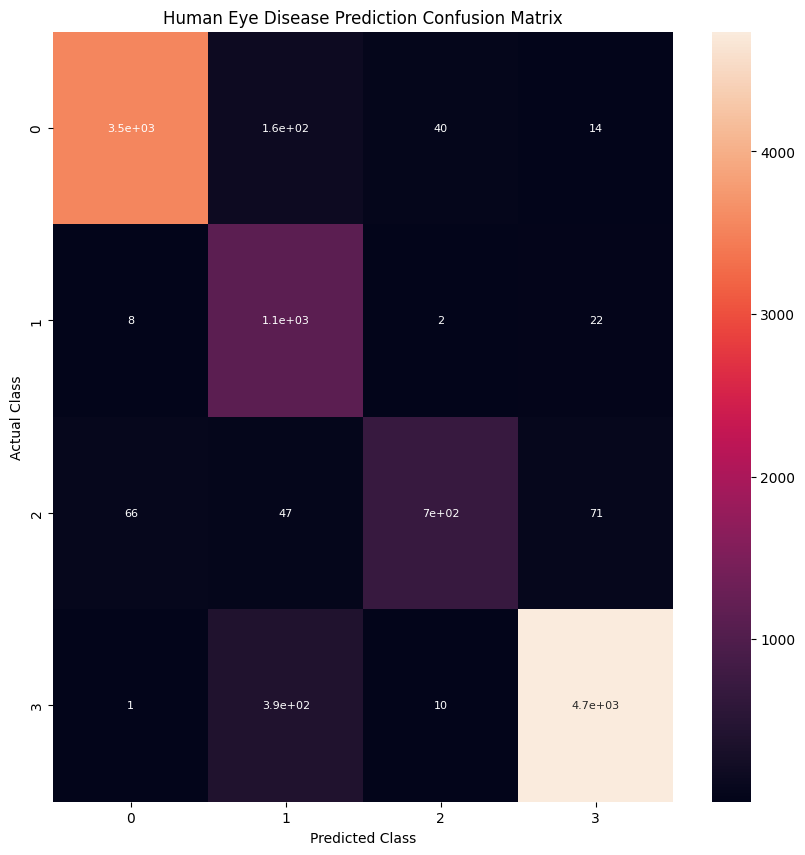

In [39]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,annot_kws={"size":8})
plt.xlabel("Predicted Class",fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("Human Eye Disease Prediction Confusion Matrix",fontsize=12)
plt.show()